Environment name: `r_env_corr`

# 0. - Imports and paths

In [85]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [1]:
suppressMessages(suppressWarnings(source("./utils/source_satac.R")))
library(biovizBase)
library(extrafont) # install.packages("extrafont")
library(Matrix)
library(ape)
library(clustree)

Registering fonts with R



Loading the fonts.

In [2]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf 
# or, better, https://fonts.google.com/specimen/DM+Sans
# Import only DMSans-Medium
# font_import(paths = "../fonts/static/", prompt = FALSE, recursive = FALSE, pattern = "DMSans-Medium.ttf") # select just the Medium one
# loadfonts()  # Load registered fonts

# # verify if the font is available:
# fonts()

In [3]:
# # for font in Base R plots
# par(family = "DM Sans Medium")
# plot(1: 2, main = "Title in Custom Font")

sATAC sample paths.

In [4]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"
PATH_sATAC_PREPROCESSING_OUTPUT <- "output/sATAC_preprocessing/"
PATH_TO_FIGURES <- "figures/sATAC_preprocessing/"

SELECTED_sATAC_SAMPLE <- "220327_C1"

Visium sample paths.

In [5]:
VISIUM_SAMPLE_NAME <- "FFPE"
PATH_TO_VISIUM_PROCESSED_FOLDER <- "output/Visium_preprocessing/"

PATH_TO_VISIUM_SAMPLE <- "../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"

PATH_TO_VISIUM_ORIGINAL_SPOTFILE <- "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_positions_list.csv"
PATH_TO_NECROSIS_SPOTS <- "../data/visium_ffpe/output_n_suppl_files/spatial/Visium_FFPE_selected_necrosis_spots_v2.csv"
# PATH_TO_VISIUM_MOD_SPOTFILE <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_VISIUM_MOD_SPOTFILE <- "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv"
PATH_TO_VISIUM_CORRECTED_SPOTFILE <- "output/Visium_preprocessing/FFPE_correct_tissue_positions_list.csv"


PATH_TO_VISIUM_HIGH_RES_IMAGE <- "../data/visium_ffpe/output_n_suppl_files/spatial/tissue_hires_image.png"
PATH_TO_VISIUM_JSON <- "../data/visium_ffpe/output_n_suppl_files/spatial/scalefactors_json.json"

---
# 1. - Loading the previously created object

In [6]:
# load seurat object with denoised gene activity counts - This takes around 40 mins
# satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "4_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA.rds"))
# satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "4_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA2.rds"))
satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "4_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA_from_satac_part.rds"))

In [7]:
satac_selected

An object of class Seurat 
254820 features across 3538 samples within 3 assays 
Active assay: RNA (19522 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: peaks, RNA_dca
 3 dimensional reductions calculated: lsi, umap, pca

In [8]:
levels(satac_selected@meta.data$seurat_clusters)
# levels(satac_selected@meta.data$seurat_clusters_rna)

[1] "0" "1" "2" "3" "4" "5"

In [9]:
# link peaks to genes
markers <- FindAllMarkers(satac_selected, logfc.threshold = 0.1, only.pos = T, assay = "RNA") %>%
  filter(p_val_adj < 0.05)

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5



In [10]:
DefaultAssay(satac_selected) <- "peaks"
satac_selected <- RegionStats(satac_selected, genome = BSgenome.Hsapiens.UCSC.hg38)

This chunks takes a lot of time to run.

In [11]:
# satac_selected <- LinkPeaks(
#   object = satac_selected,
#   peak.assay = "peaks",
#   expression.assay = "RNA_dca",
#   genes.use = unique(markers$gene),
#   min.distance = 2000
# )

# linked_peaks <- satac_selected@assays[["peaks"]]@links@elementMetadata %>% as.data.frame()

In [12]:
# write.csv(linked_peaks, "output/sATAC_preprocessing/linked_peaks_temp.csv")
# saveRDS(satac_selected, "output/sATAC_preprocessing/linked_peaks_temp.RDS")

In [13]:
linked_peaks <- read.csv(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "linked_peaks_", SELECTED_sATAC_SAMPLE, "_temp.csv"), row.names=1)

# 3. - Loading the Visium assay

Tutorial: https://satijalab.org/seurat/articles/spatial_vignette

In [14]:
mod_spotfile <- read.csv(PATH_TO_VISIUM_MOD_SPOTFILE, row.names = 1, )
necrosis_spotfile <- read.csv(PATH_TO_NECROSIS_SPOTS)

Choosing the overlapping spots by leveraging on the color chosen for the clustering. If there is no color, it means that the spot is not in tissue at all, or it was removed after the original processing.

In [15]:
head(necrosis_spotfile)
dim(necrosis_spotfile)

,Barcode,Necrosis.spots
,<chr>,<chr>
1,AAACAAGTATCTCCCA-1,necrosis
2,AAAGGCTACGGACCAT-1,necrosis
3,AAATCTAGCCCTGCTA-1,necrosis
4,AAATGGTCAATGTGCC-1,necrosis
5,AAATTACACGACTCTG-1,necrosis
6,AACAATACATTGTCGA-1,necrosis


[1] 310   2

In [16]:
mod_spotfile$barcode <- paste0(mod_spotfile$barcode, "_1")
necrosis_spotfile$Barcode <- paste0(necrosis_spotfile$Barcode, "_1")
head(mod_spotfile)

,barcode,in_tissue,array_row,array_col,pxl_row,pxl_col,image_name,Cluster,R,G,B
,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0,AAACAACGAATAGTTC-1_1,0,0,16,3635,7471,,NA,NA,NA,NA
1,AAACAAGTATCTCCCA-1_1,1,50,102,16265,19934,,NA,NA,NA,NA
2,AAACAATCTACTAGCA-1_1,0,3,43,4395,11387,,NA,NA,NA,NA
3,AAACACCAATAACTGC-1_1,1,59,19,18526,7893,AAACACCAATAACTGC-1_row59_col19_100um.jpg,4,59,163,236
4,AAACAGAGCGACTCCT-1_1,1,14,94,7178,18782,AAACAGAGCGACTCCT-1_row14_col94_100um.jpg,3,53,172,164
5,AAACAGCTTTCAGAAG-1_1,1,43,9,14487,6446,AAACAGCTTTCAGAAG-1_row43_col9_100um.jpg,4,59,163,236


In [17]:
table(mod_spotfile$in_tissue)


   0    1 
2474 2518 

In [18]:
sum(table(mod_spotfile$R))

[1] 2208

In [19]:
# temp_just_included_spots <- mod_spotfile$barcode[which(!is.na(mod_spotfile$Cluster) && !mod_spotfile$Barcode)]
temp_just_included_spots <- mod_spotfile$barcode[!is.na(mod_spotfile$Cluster)] 
temp_just_included_spots <- temp_just_included_spots[!temp_just_included_spots %in% necrosis_spotfile$Barcode]
length(temp_just_included_spots)


[1] 2208

In [20]:
length(setdiff(mod_spotfile$barcode[is.na(mod_spotfile$Cluster)], necrosis_spotfile$Barcode))
length(setdiff(necrosis_spotfile$Barcode, mod_spotfile$barcode[is.na(mod_spotfile$Cluster)]))

[1] 2474

[1] 0

In [21]:
# excluded_spots <- setdiff(mod_spotfile$barcode, temp_just_included_spots)
# length(excluded_spots)

In [22]:
correct_format_spotfile <- mod_spotfile[which(mod_spotfile$in_tissue == 1), 1:6]
# correct_format_spotfile <- temp_excluded_spots %>%
#         filter(temp_excluded_spots$in_tissue == 1)

head(correct_format_spotfile)
dim(correct_format_spotfile)

,barcode,in_tissue,array_row,array_col,pxl_row,pxl_col
,<chr>,<int>,<int>,<int>,<int>,<int>
1,AAACAAGTATCTCCCA-1_1,1,50,102,16265,19934
3,AAACACCAATAACTGC-1_1,1,59,19,18526,7893
4,AAACAGAGCGACTCCT-1_1,1,14,94,7178,18782
5,AAACAGCTTTCAGAAG-1_1,1,43,9,14487,6446
6,AAACAGGGTCTATATT-1_1,1,47,13,15497,7025
13,AAACCGGGTAGGTACC-1_1,1,42,28,14237,9202


[1] 2518    6

In [23]:
write.csv(correct_format_spotfile, PATH_TO_VISIUM_CORRECTED_SPOTFILE)

In [24]:
## visium - create seurat object with stutility 
infoTable <- data.frame(
  samples = PATH_TO_VISIUM_SAMPLE,
  spotfiles = PATH_TO_VISIUM_ORIGINAL_SPOTFILE,
  imgs = PATH_TO_VISIUM_HIGH_RES_IMAGE,
  json = PATH_TO_VISIUM_JSON
)

In [25]:
# counts <- Read10X_h5("../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5")
# print(dim(counts))  # Should match expected dimensions

In [26]:

visium <- InputFromTable(infotable = infoTable, 
                     min.gene.count = 0, 
                     min.gene.spots = 0,
                     min.spot.count = 0,
                    #  scaleVisium = 1,
                     platform =  "Visium"
                     )
visium <- LoadImages(visium)

Warning message in InputFromTable(infotable = infoTable, min.gene.count = 0, min.gene.spots = 0, :
"min.gene.counts has been deprecated, please use minUMICountsPerGene instead"
Warning message in InputFromTable(infotable = infoTable, min.gene.count = 0, min.gene.spots = 0, :
"min.gene.spots has been deprecated, please use minUMICountsPerGene instead"
Warning message in InputFromTable(infotable = infoTable, min.gene.count = 0, min.gene.spots = 0, :
"min.spot.count has been deprecated, please use minUMICountsPerSpot instead"


Using spotfiles to remove spots outside of tissue
Loading ../data/visium_ffpe/output_n_suppl_files/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5 count matrix from a 'Visium' experiment

------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  292  
Saving capture area ranges to Staffli object 
After filtering the dimensions of the experiment is: [17651 genes, 2518 spots] 
Loading images for 1 samples: 
  Reading ../data/visium_ffpe/output_n_suppl_files/spatial/tissue_hires_image.png for sample 1 ... 
  Scaling down sample 1 image from 2000x1839 pixels to 400x368 pixels 


Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'



In [27]:
colnames(correct_format_spotfile) <- c("barcode", "in_tissue", "array_row", "array_col", "pxl_row_in_fullres", "pxl_col_in_fullres")

In [28]:
length(setdiff(rownames(visium@meta.data), correct_format_spotfile$barcode))
length(setdiff(correct_format_spotfile$barcode, rownames(visium@meta.data)))

[1] 0

[1] 0

Let's choose only the spots that are really in the tissue.

In [29]:
length(rownames(visium@meta.data))
length(temp_just_included_spots)

visium <- subset(visium, cells = temp_just_included_spots)

length(rownames(visium@meta.data))

[1] 2518

[1] 2208

[1] 2208

In [30]:
# visium@tools$Staffli@meta.data

In [31]:
# rownames(new_spot_coords) <- new_spot_coords$barcode
# visium@meta.data <- merge(visium@meta.data, new_spot_coords, by = "row.names", all.x = TRUE)
# visium@meta.data <- correct_format_spotfile

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


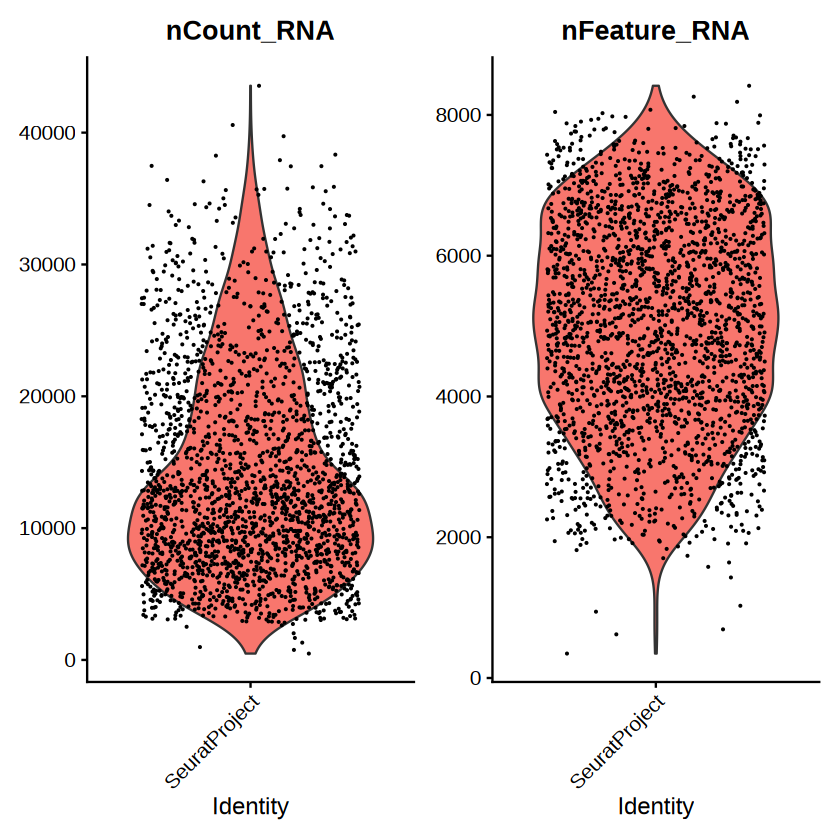

In [32]:
VlnPlot(visium, features = c("nCount_RNA", "nFeature_RNA"), ncol = 2) + NoLegend()

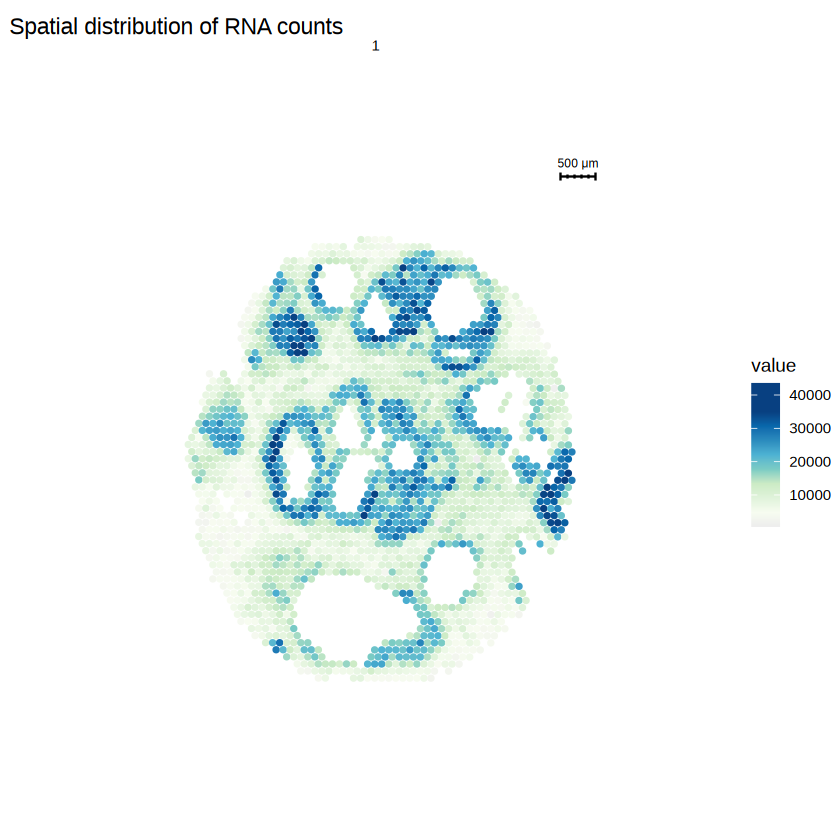

In [33]:
# SpatialFeaturePlot(visium, features = "nCount_RNA") + theme(legend.position = "right")
# DefaultAssay(signac_selected) <- 'peaks'

ST.FeaturePlot(visium, 
                'nCount_RNA', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of RNA counts"))

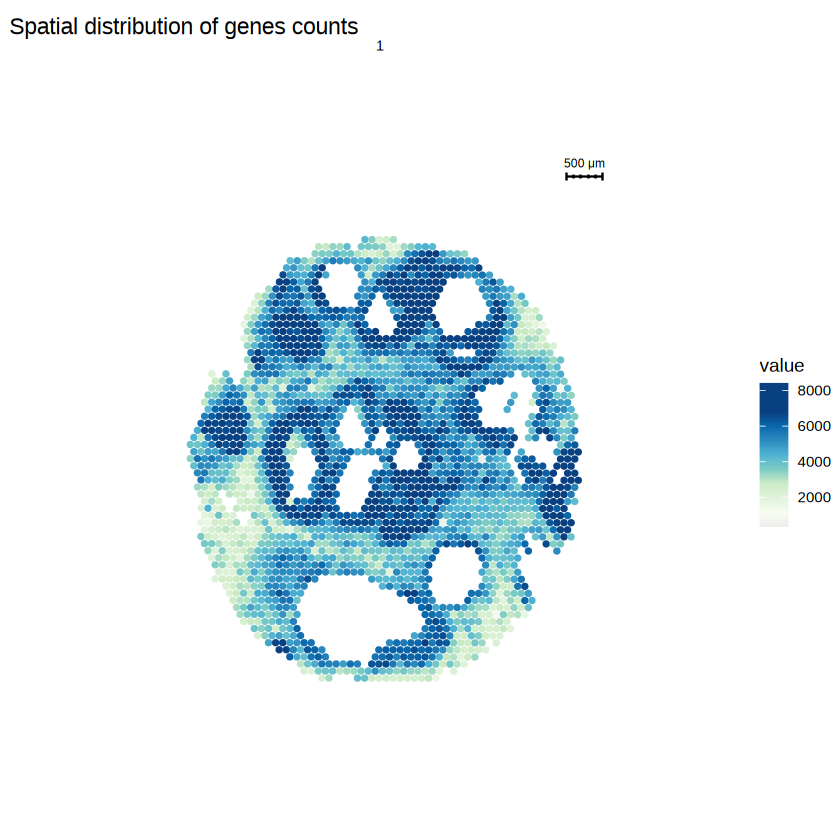

In [34]:
ST.FeaturePlot(visium, 
                'nFeature_RNA', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of genes counts"))

In [35]:
visium <- visium %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA()

# visium <- SCTransform(visium, assay = "RNA", verbose = FALSE)
# visium <- RunPCA(visium, assay = "SCT", verbose = FALSE)

PC_ 1 
Positive:  IGKC, IGHG2, APOE, LYZ, TYROBP, IGHG1, JCHAIN, CD163, GPNMB, SFRP4 
	   CTSB, PTGDS, PTPRC, LSP1, MPEG1, IGHA1, CD68, CORO1A, CD37, CD53 
	   A2M, ITGB2, TIMP1, TGFBI, HMOX1, IGLC1, APOC1, TRBC2, IFI30, IGHM 
Negative:  PPDPF, AZGP1, ERBB2, KRT7, CD24, MAL2, ATG5, SPINT2, KRT8, FOXA1 
	   PSMD3, TACSTD2, ORMDL3, EPCAM, KIAA1324, ARPC1A, CLDN4, MED24, ARPC1B, MUCL1 
	   SERINC2, DHCR24, MSL1, PITX1, MLPH, CRABP2, KRT18, LLGL2, MIEN1, TPD52 
PC_ 2 
Positive:  HMOX1, FGG, FGA, CAPN13, AGT, FGB, SERPINA3, GPX3, ANGPTL4, CTSB 
	   TGFBI, LBP, WFDC2, SPP1, ORM1, LTF, CTSL, WDR86, TGM2, FMO2 
	   TAGLN, ACTA2, NUPR1, CLU, SLC11A1, RARRES1, COL12A1, MGP, WLS, TIMP1 
Negative:  CXCL9, IFITM1, CCL5, TRAC, IFI44L, TRBC2, TRBC1, IFI44, ISG20, IDO1 
	   IL7R, TAP1, LTB, LAMP3, ISG15, OAS2, CXCL11, BIRC3, CCR7, SELL 
	   CD3D, OASL, CXCL13, OAS3, MX1, GBP4, GBP5, IFI6, TAP2, CCL19 
PC_ 3 
Positive:  COL4A1, COL4A2, ACTA2, TAGLN, MYLK, TOP2A, TIMP3, ADAMTS1, PLVAP, A2M 
	   KRT5, KD

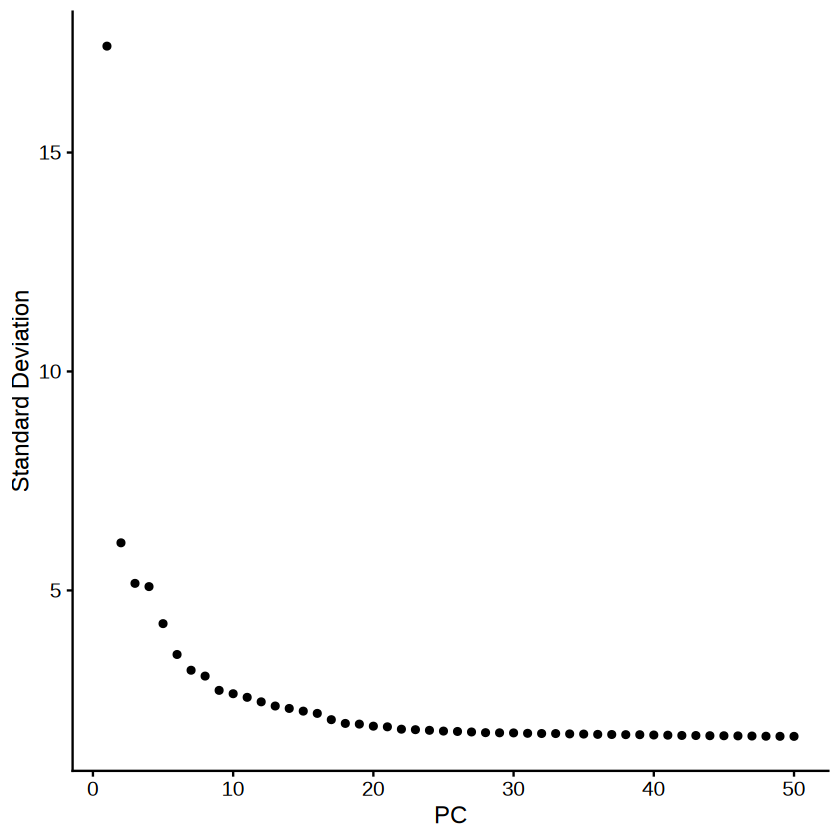

In [36]:
ElbowPlot(visium, n = 50)

In [37]:
# visium <- visium %>%
#   FindNeighbors(visium, reduction = "pca", dims = 1:15) %>%
#   FindClusters(visium, algorithm = 4, verbose = FALSE) %>%
#   RunUMAP(visium, reduction = "pca", dims = 1:15)

In [38]:
visium <- visium %>%
  RunUMAP(dims = 1:20, verbose = FALSE) %>%
  FindNeighbors( dims = 1:20, verbose = FALSE) %>%
  FindClusters(resolution = 0.6, algorithm = 4, 
    verbose = FALSE)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


In [39]:
table(visium@meta.data$seurat_clusters)


  1   2   3   4   5   6   7   8 
519 448 379 316 251 188  56  51 

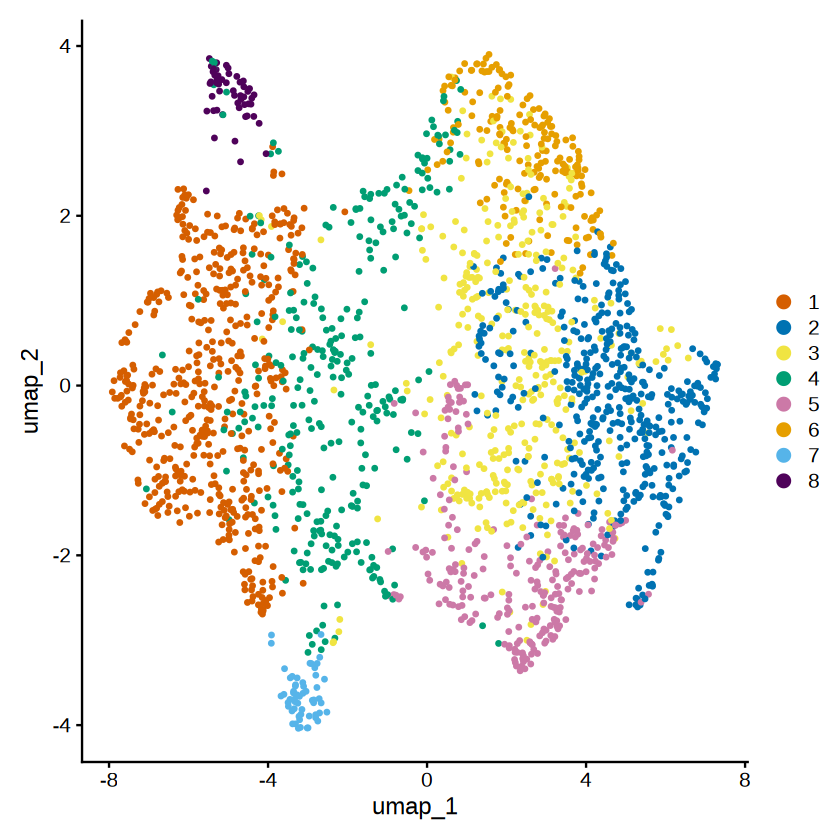

In [40]:
DimPlot(visium, 
        reduction = "umap", 
        cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#4f025a")
)

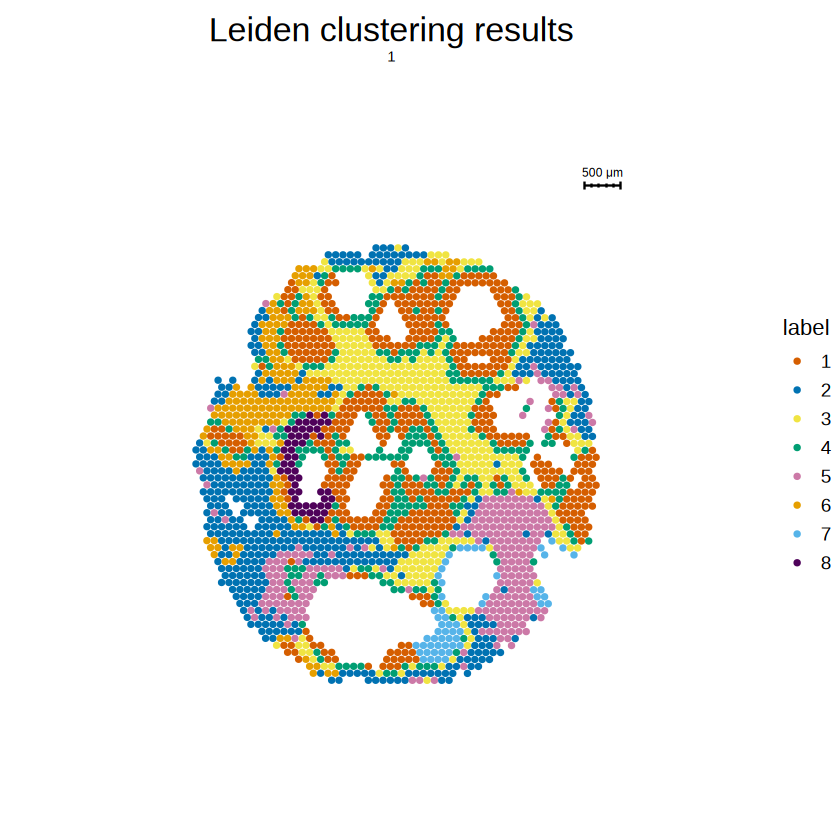

In [41]:
ST.FeaturePlot(visium, 
                features = "seurat_clusters", 
                cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#4f025a"),
                pt.size = 1.8) +
         ggtitle("Leiden clustering results") +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))

In [42]:
head(visium@reductions$pca@cell.embeddings)

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,⋯,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50
GTAGACAACCGATGAA-1_1,7.586376,1.406561,-0.8307977,0.7774776,-3.5455619,-4.627632,1.6143188,-0.8117734,3.5961132,2.8272129,⋯,1.468574376,-1.78415885,-1.706847,-3.11697514,1.953910,-0.9552861,1.3091550,-0.5900872,1.0035969,4.032863
ACAGATTAGGTTAGTG-1_1,2.121550,1.963555,0.5078332,-0.3548056,-2.4014113,-5.631085,2.0203616,-0.3810366,2.4945203,2.3767435,⋯,1.748500873,0.48932423,-1.484919,0.05043333,1.026934,-1.5547779,0.9650481,-0.2896170,-3.2013936,4.987146
TGGTATCGGTCTGTAT-1_1,8.913691,5.055793,-1.0936608,1.3816840,-1.5254103,-7.240291,-2.4223054,-2.8925860,4.3642828,4.4138880,⋯,0.006978485,-0.79904011,6.334796,1.43935198,-2.686985,-3.5087093,-1.0205573,1.9342646,1.0994412,-4.654435
ATTATCTCGACAGATC-1_1,2.194807,4.781824,-3.1166339,3.2237503,0.7297884,-4.615818,-2.1683930,-1.1066688,-0.7557865,1.3856511,⋯,-0.920035817,-3.75908348,-3.706732,-0.49518001,3.955668,-0.3292608,4.7263376,-0.6032052,0.1874816,-3.282062
TGAGATCAAATACTCA-1_1,3.046287,3.699381,-1.8994232,2.1813343,1.1665511,-6.433788,-1.0196945,-1.7971634,1.5799440,0.1594171,⋯,-2.301165258,-2.64332772,-2.013733,3.00371918,1.574446,-1.5262911,-0.3072369,-7.4795791,-3.1455653,4.675322
CAACTTGTAGTGGGCA-1_1,10.165226,1.536537,-1.4828561,4.4973719,-1.7991704,-2.336312,-0.8639029,-0.3605037,1.0805279,-0.3813302,⋯,-0.189142835,-0.01604659,2.126821,-1.35077741,-1.228701,-2.6256124,2.4664962,1.8807792,-1.5090406,2.402804


Clustering with K-Means.

In [43]:
DefaultAssay(visium) <- "RNA"

In [44]:
visium[["kmeans_6"]] <- kmeans(visium@reductions$pca@cell.embeddings, 6, algorithm = "Lloyd", iter.max = 300)$cluster
visium$kmeans_6 <- as.factor(visium$kmeans_6)

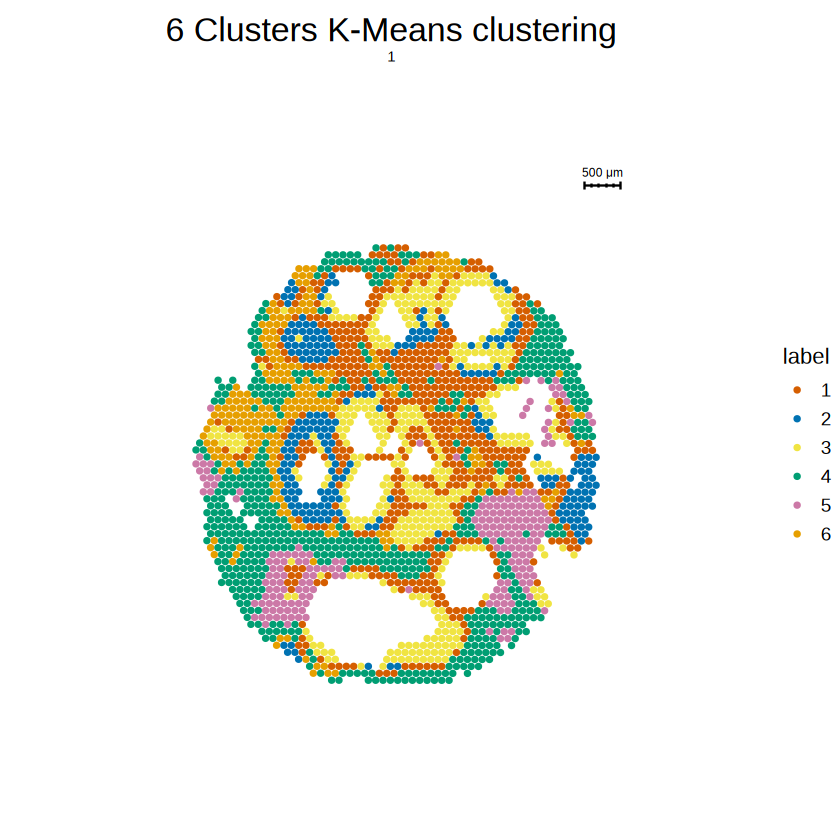

In [45]:
ST.FeaturePlot(visium, 
                features = "kmeans_6", 
                cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
                pt.size = 1.8) +
         ggtitle("6 Clusters K-Means clustering") +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(), # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))

In [46]:
# write.csv(as.matrix(visium@assays$RNA$counts), paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "gene_counts_", VISIUM_SAMPLE_NAME, ".csv"))

---
Denoise the counts

In [47]:
# load denoised visium data
dca_counts <- read.table(paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "dca_gene_counts_", VISIUM_SAMPLE_NAME, "/mean.tsv"))

In [48]:

colnames(dca_counts) <- gsub("\\.", "-", colnames(dca_counts))
visium <- subset(visium, cells = colnames(dca_counts))
visium[["RNA_dca"]] <- CreateAssayObject(counts = as.matrix(dca_counts))
#rm(dca_counts)

In [49]:
DefaultAssay(visium) <- "RNA_dca"
visium <- AddMetaData(visium, metadata = Matrix::colSums(as.matrix(dca_counts) > 0), col.name = "nFeature_RNA_dca")

In [50]:
head(visium@meta.data$nCount_RNA)
head(visium@meta.data$nFeature_RNA)

[1] 9842 6511 3817 4774 5935 6324

[1] 4214 3496 2411 2705 3164 3420

In [51]:
head(visium@meta.data$nCount_RNA_dca)
head(visium@meta.data$nFeature_RNA_dca)

[1] 9060.073 6536.104 3709.100 4780.493 6231.476 6287.173

[1] 17606 17606 17606 17606 17606 17606

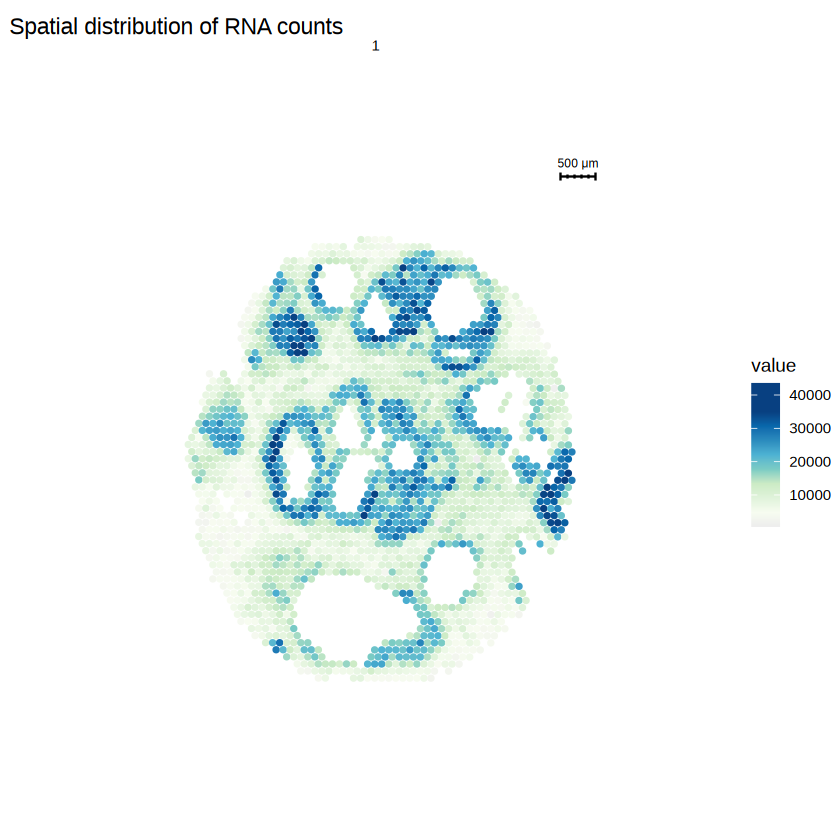

In [52]:
ST.FeaturePlot(visium, 
                'nCount_RNA', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of RNA counts"))

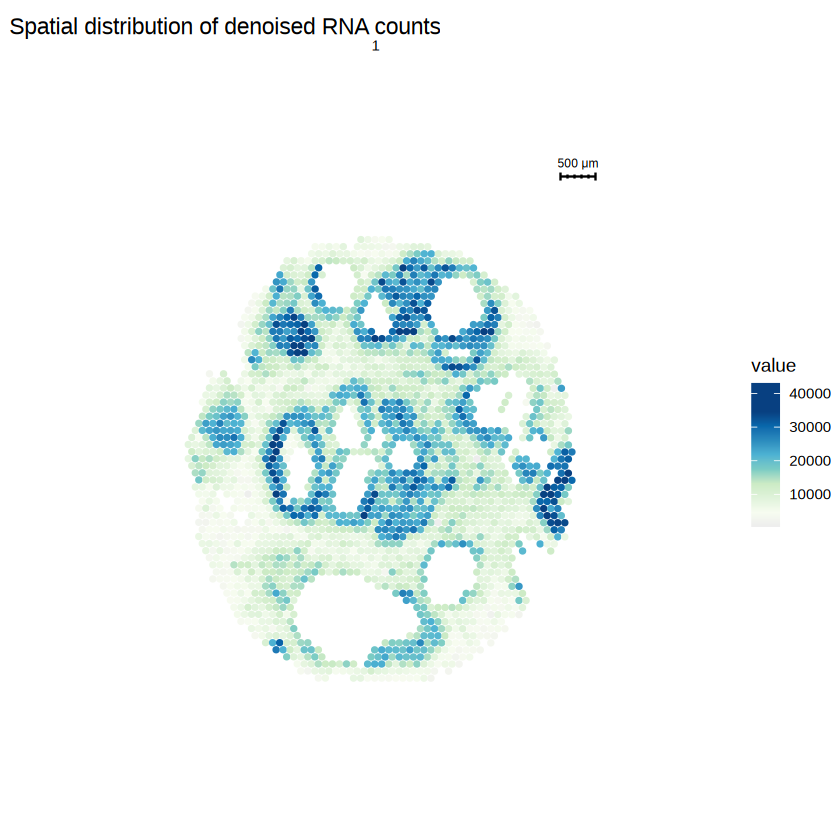

In [53]:
# SpatialFeaturePlot(visium, features = "nCount_RNA") + theme(legend.position = "right")
# DefaultAssay(signac_selected) <- 'peaks'

ST.FeaturePlot(visium, 
                'nCount_RNA_dca', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of denoised RNA counts"))

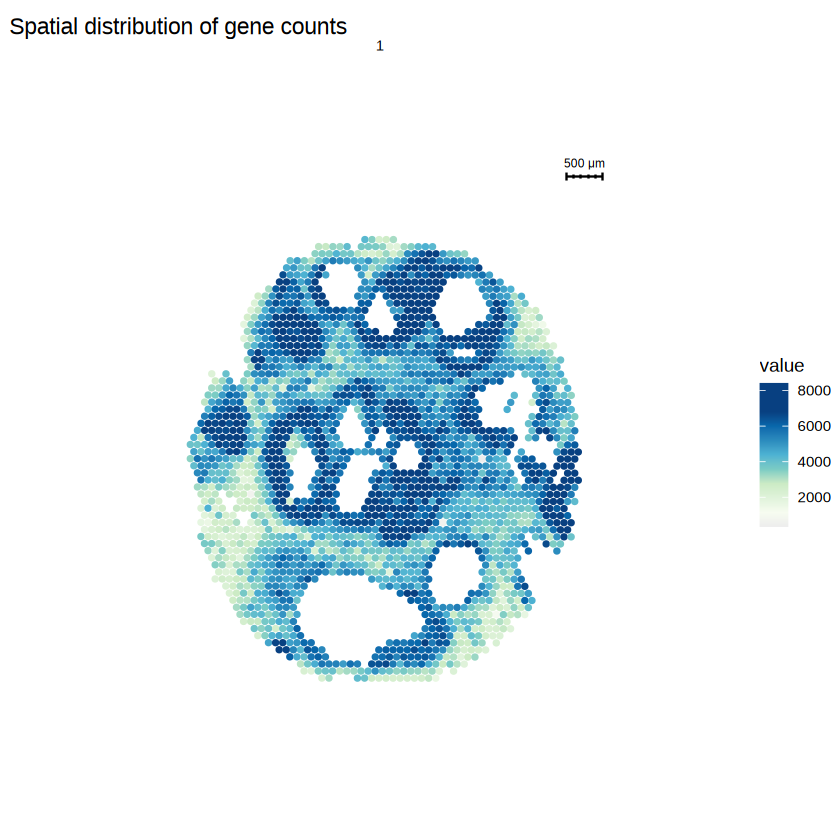

In [54]:
ST.FeaturePlot(visium, 
                'nFeature_RNA', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of gene counts"))

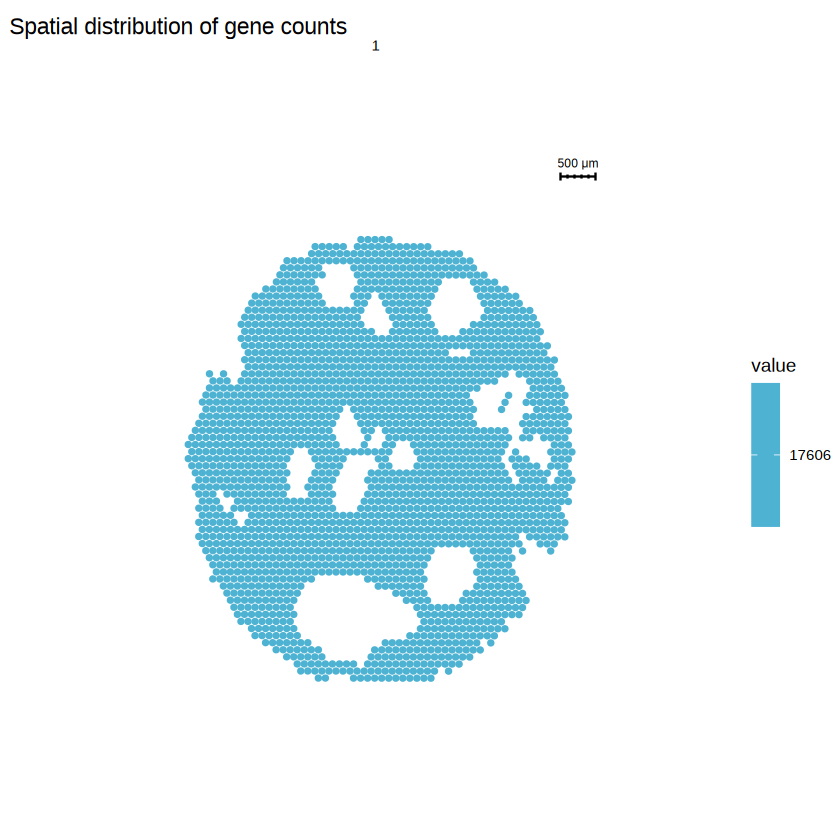

In [55]:
ST.FeaturePlot(visium, 
                'nFeature_RNA_dca', 
                cols = cyan_scale,
                # min.cutoff = 'q1', 
                # max.cutoff = 'q99',
                pt.size = 1.8) +
        ggtitle(paste("Spatial distribution of gene counts"))

In [56]:
visium <- visium %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA(verbose = FALSE)

# visium <- SCTransform(visium, assay = "RNA", verbose = FALSE)
# visium <- RunPCA(visium, assay = "SCT", verbose = FALSE)

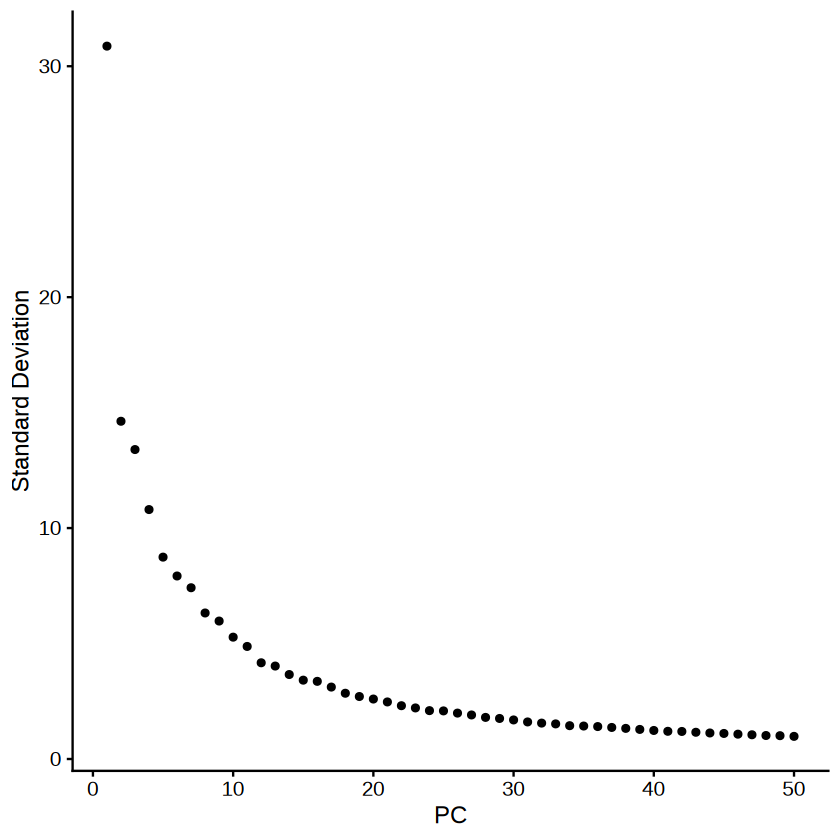

In [57]:
ElbowPlot(visium, n = 50)

In [58]:
# visium <- visium %>%
#   FindNeighbors(visium, reduction = "pca", dims = 1:15) %>%
#   FindClusters(visium, algorithm = 4, verbose = FALSE) %>%
#   RunUMAP(visium, reduction = "pca", dims = 1:15)

In [59]:
visium <- visium %>%
  RunUMAP(dims = 1:25, verbose = FALSE) %>%
  FindNeighbors( dims = 1:25, verbose = FALSE) %>%
  FindClusters(resolution = 0.6, algorithm = 4, 
    verbose = FALSE)

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


In [60]:
table(visium@meta.data$seurat_clusters)


  1   2   3   4   5   6   7   8 
553 358 357 280 247 195 144  74 

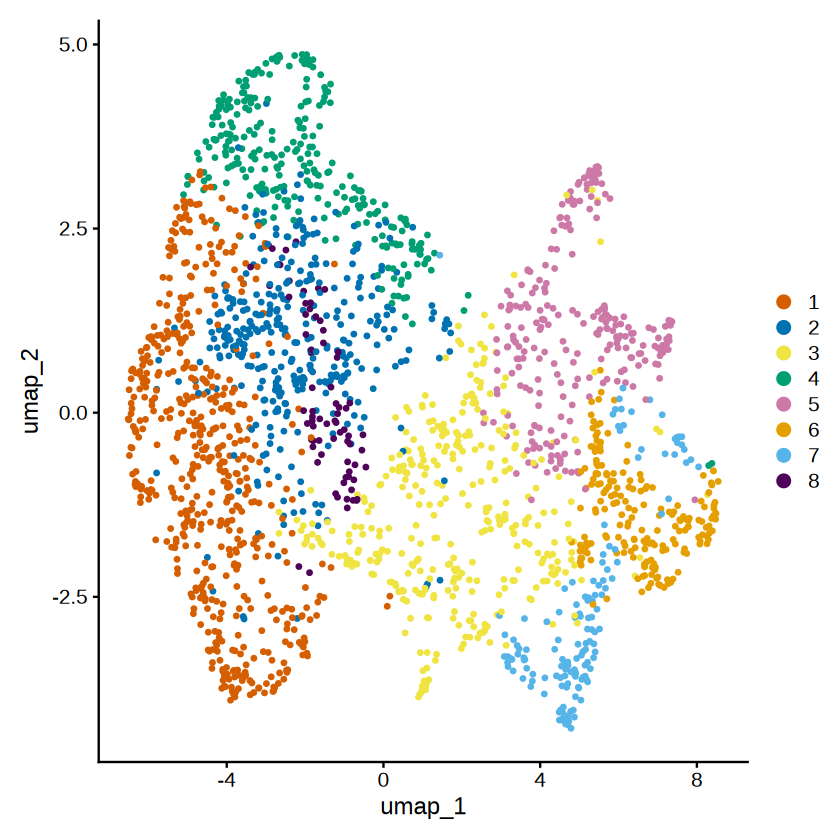

In [61]:
DimPlot(visium, 
        reduction = "umap", 
        cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#4f025a")
)

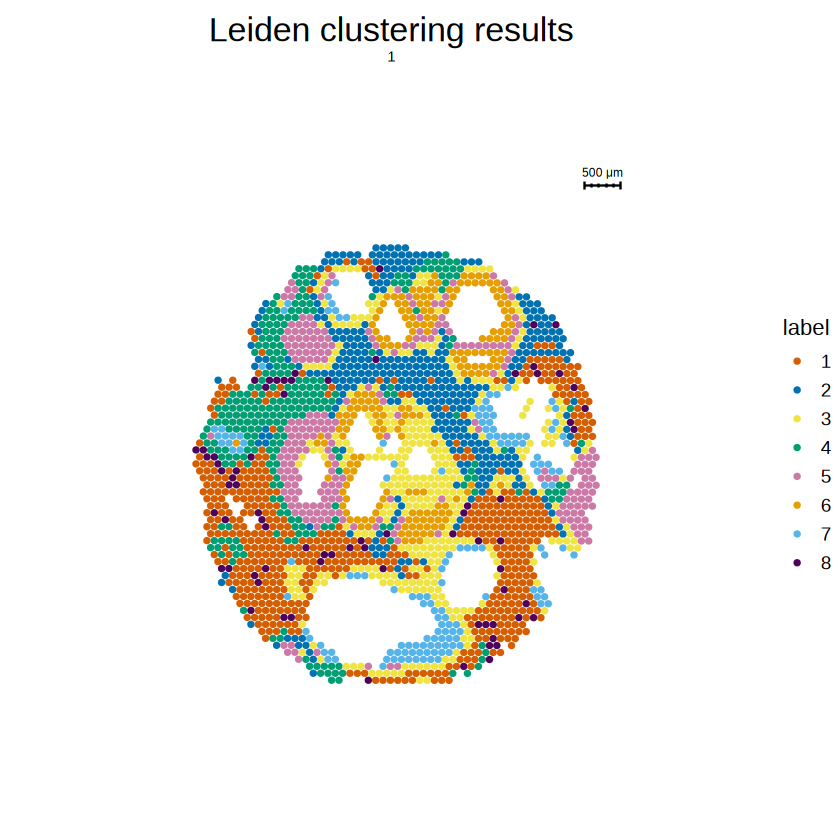

In [62]:
ST.FeaturePlot(visium, 
                features = "seurat_clusters", 
                cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#4f025a"),
                pt.size = 1.8) +
         ggtitle("Leiden clustering results") +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))

In [63]:
visium@reductions$pca@cell.embeddings[1:5, 1:8]

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8
GTAGACAACCGATGAA-1_1,-10.5617127,-2.491222,0.03704933,9.173526,5.579812,8.14624513,-0.6523466,1.99563687
ACAGATTAGGTTAGTG-1_1,-2.2172647,-5.420922,-0.89638335,2.780515,5.401588,4.13516216,-4.8944397,0.80574578
TGGTATCGGTCTGTAT-1_1,-3.6969713,-3.639722,-1.22012623,5.258215,6.424573,3.11029973,-2.1871208,0.03862999
ATTATCTCGACAGATC-1_1,-0.1197775,-13.110904,3.89739191,6.803839,3.078565,0.04445032,0.8594022,4.60894797
TGAGATCAAATACTCA-1_1,-4.5323999,-8.126087,2.57397165,7.826130,1.028015,3.37455315,3.1483904,4.30597032


Clustering with K-Means.

In [64]:
visium[["kmeans_6_dca"]] <- kmeans(visium@reductions$pca@cell.embeddings, 6, algorithm = "Lloyd", iter.max = 300)$cluster
visium$kmeans_6_dca <- as.factor(visium$kmeans_6_dca)

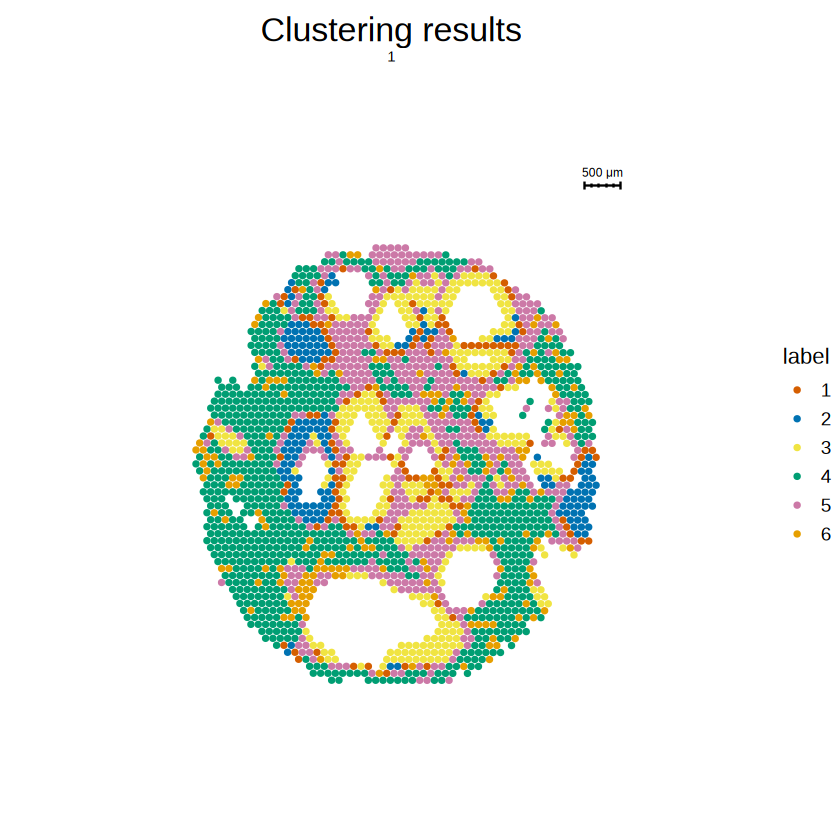

In [65]:
ST.FeaturePlot(visium, 
                features = "kmeans_6_dca", 
                cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
                pt.size = 1.8) +
              ggtitle("Clustering results") +
              theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(), # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13)) #+
              # scale_fill_manual(values = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
              #   name = "Cluster")

In [66]:
# DefaultAssay(visium) <- "RNA"
# ST.FeaturePlot(visium, "ERBB2", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1")
# ST.FeaturePlot(visium, "C1QB", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1")

In [67]:
# DefaultAssay(visium) <- "RNA_dca"
# ST.FeaturePlot(visium, "ERBB2", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1")
# ST.FeaturePlot(visium, "C1QB", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1")


In [68]:
satac_selected

An object of class Seurat 
254820 features across 3538 samples within 3 assays 
Active assay: peaks (215978 features, 215978 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, RNA_dca
 3 dimensional reductions calculated: lsi, umap, pca

In [69]:
# DefaultAssay(satac_selected) <- "RNA_dca"
# p1 <- ST.FeaturePlot(satac_selected, "ERBB2", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("Spatial representation of ERBB2 denoised gene activity."))
# p2 <- ST.FeaturePlot(satac_selected, "C1QB", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("Spatial representation of C1QB denoised gene activity."))

# DefaultAssay(satac_selected) <- "peaks"
# # "chr17-39723461-39723962" ERBB2 regulatory region from paper
# # "chr1-22652746-22653247" C1QB regulatory region from paper
# p3 <- ST.FeaturePlot(satac_selected, "chr17-39723461-39723962", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("ERBB2 associated regulatory region accessibility."))
# p4 <- ST.FeaturePlot(satac_selected, "chr1-22652746-22653247", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("C1QB associated regulatory region accessibility."))

# DefaultAssay(satac_selected) <- "peaks"
# # "chr17-39723461-39723962" q
# p3 <- ST.FeaturePlot(satac_selected, "chr17-39723461-39723962", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("ERBB2 associated regulatory region accessibility."))
# p4 <- ST.FeaturePlot(satac_selected, "chr1-22652746-22653247", cols = magenta_scale, max.cutoff = "q99", indices = 1, min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("C1QB associated regulatory region accessibility."))

# DefaultAssay(visium) <- "RNA_dca"
# p5 <- ST.FeaturePlot(visium, "ERBB2", cols = cyan_scale, max.cutoff = "q95", min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("Spatial representation of ERBB2 denoised ST gene expression."))
# p6 <- ST.FeaturePlot(visium, "C1QB", cols = cyan_scale, max.cutoff = "q99", min.cutoff = "q1", pt.size = 1.8) +
#         ggtitle(paste("Spatial representation of C1QB denoised ST gene expression."))

# p1
# p2
# p3

# p4
# p5
# p6

In [70]:
# saveRDS(satac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, ".rds"))
# saveRDS(visium, paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, ".rds"))

In [71]:
# saveRDS(satac_selected, paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))
# saveRDS(visium, paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))

In [72]:
# satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, ".rds"))
# visium <- readRDS(paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, ".rds"))

---
# 4. - Comparison with scRNA-seq

Remeber to change the names of the files inside the scRNA-seq folder.

Downloaded from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176078

```sh
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078%5FWu%5Fetal%5F2021%5FBRCA%5FscRNASeq%2Etar%2Egz
```

And remember to change the names of the files:
```sh
mv count_matrix_barcodes.tsv barcodes.tsv
mv count_matrix_genes.tsv genes.tsv
mv count_matrix_sparse.mtx matrix.mtx
```

In [73]:
# compare sATAC with scRNA-seq
## scRNA-seq atlas of BRCA obtained from https://www.nature.com/articles/s41588-021-00911-1
meta_sc <- read.csv("../data/Wu_etal_2021_BRCA_scRNASeq/metadata.csv", row.names = 1)
mtx <- Read10X("../data/Wu_etal_2021_BRCA_scRNASeq/", gene.column = 1)

In [74]:
# preprocess single cell data
sc_obj <- CreateSeuratObject(mtx, meta.data = meta_sc) %>%
  NormalizeData() %>%
  FindVariableFeatures() %>%
  ScaleData()


Normalizing layer: counts

Finding variable features for layer counts



Centering and scaling data matrix



In [75]:
# label transfer using the original authors' classification of cell types
transfer.anchors <- FindTransferAnchors(reference = sc_obj, 
                                        query = visium, 
                                        features = VariableFeatures(sc_obj), 
                                        reference.assay = "RNA", 
                                        query.assay = "RNA_dca", 
                                        reduction = "cca")


Warning message:
"475 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 1525 features."
Running CCA

Merging objects



Finding neighborhoods

Finding anchors

	Found 8920 anchors



In [76]:
celltype.predictions <- TransferData(anchorset = transfer.anchors, 
                                     refdata = sc_obj$celltype_major, 
                                     weight.reduction = visium[["pca"]],
                                     dims = 1:15)

visium <- AddMetaData(visium, metadata = celltype.predictions)

Finding integration vectors

Finding integration vector weights



Predicting cell labels



In [77]:
# new adapted way
desired_order <- c(
  "Cancer Epithelial", "Normal Epithelial", "Myeloid",
  "B-cells", "Plasmablasts", "T-cells", "CAFs",
  "Endothelial", "PVL"
)

# Clean names for lookup and plotting
clean_names <- make.names(desired_order)  # Convert to column format (dots instead of spaces/dashes)
prediction_features <- paste0("prediction.score.", clean_names)
names(prediction_features) <- desired_order  # Set pretty labels


Warning message:
"The `facets` argument of `facet_grid()` is deprecated as of ggplot2 2.2.0.
ℹ Please use the `rows` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


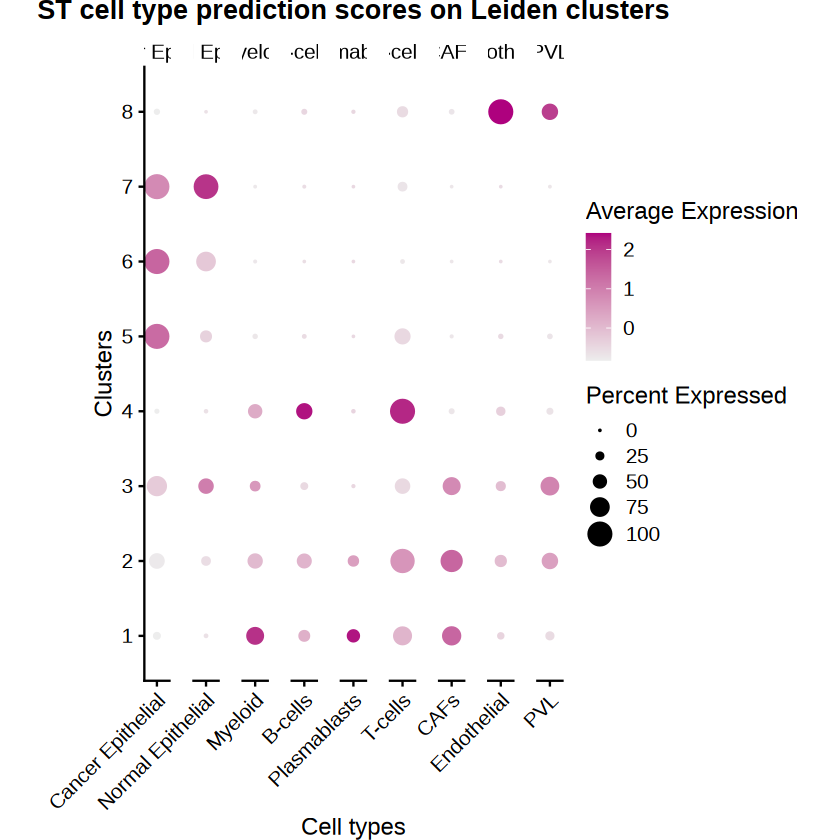

In [78]:

# Now plot
DotPlot(visium, features = prediction_features, cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("ST cell type prediction scores on Leiden clusters")
ggsave("dotplot_predictions_leiden_clusters_visium.png", width = 8, height = 5, units = "in", dpi = 300)

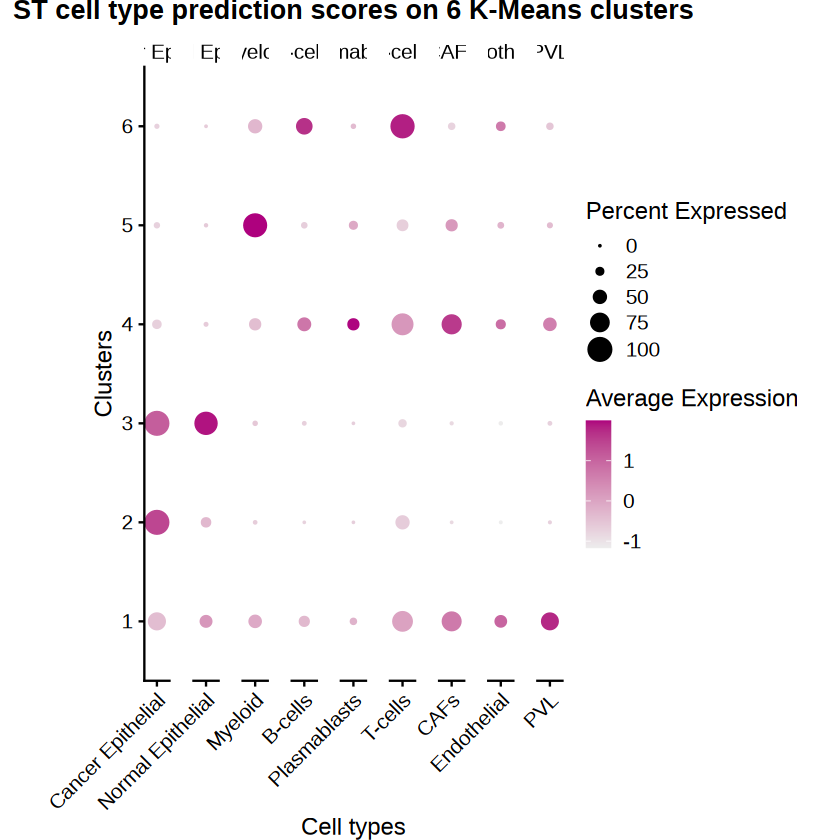

In [79]:
# Now plot
DotPlot(visium, features = prediction_features, group.by = "kmeans_6", cols = c("gray93", "#AE017E")) +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  scale_y_discrete(name = "Clusters") +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(hjust = 0.5),
    plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
  ) +
  ggtitle("ST cell type prediction scores on 6 K-Means clusters")
ggsave("dotplot_predictions_6kmeans_clusters_visium.png", width = 8, height = 5, units = "in", dpi = 300)

In [80]:
# satac_selected <- readRDS(paste0(PATH_sATAC_PREPROCESSING_OUTPUT, "final_preprocessing_sATAC_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))
# visium <- readRDS(paste0(PATH_TO_VISIUM_PROCESSED_FOLDER, "final_preprocessing_VISIUM_selected_", SELECTED_sATAC_SAMPLE, "_v2.rds"))

---
# 5. - Comparison with image clustering

Correcting input names for data and adapting the order for plotting purposes.

In [81]:
image_cluster_paths <- list(
  visium_100um_kmeans_original_wsi = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv",
  visium_100um_leiden_original_wsi = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv",
  visium_100um_kmeans_from_wsi_macenko = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv",
  visium_100um_leiden_from_wsi_macenko = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv",
  
  visium_68um_kmeans_original_wsi = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv",
  visium_68um_leiden_original_wsi = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv",
  visium_68um_kmeans_from_wsi_macenko = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv",
  visium_68um_leiden_from_wsi_macenko = "../4_clustering_and_classification/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_visium_FFPE_dcis_idc_10X_&_img_not_changed_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"
)

image_cluster_data <- lapply(image_cluster_paths, read.csv, row.names = 1)

# assign to individual variables in the global environment
list2env(image_cluster_data)

<environment: 0x559d111bb738>

In [82]:
head(visium)

,orig.ident,nCount_RNA,nFeature_RNA,id,labels,RNA_snn_res.0.6,seurat_clusters,kmeans_6,nCount_RNA_dca,nFeature_RNA_dca,⋯,prediction.score.Endothelial,prediction.score.CAFs,prediction.score.PVL,prediction.score.B.cells,prediction.score.T.cells,prediction.score.Myeloid,prediction.score.Normal.Epithelial,prediction.score.Plasmablasts,prediction.score.Cancer.Epithelial,prediction.score.max
,<fct>,<dbl>,<int>,<int>,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GTAGACAACCGATGAA-1_1,SeuratProject,9842,4214,1,Default,2,2,4,9060.073,17606,⋯,0.000000000,0.7946260,0.032080572,0.05379078,0.068661002,0.0000000,0,0.050841631,0.000000000,0.7946260
ACAGATTAGGTTAGTG-1_1,SeuratProject,6511,3496,2,Default,2,2,1,6536.104,17606,⋯,0.010149162,0.4925857,0.110609140,0.00000000,0.138172589,0.0000000,0,0.000000000,0.248483400,0.4925857
TGGTATCGGTCTGTAT-1_1,SeuratProject,3817,2411,3,Default,2,2,4,3709.100,17606,⋯,0.008948785,0.5437952,0.140950000,0.00000000,0.151505848,0.0000000,0,0.000000000,0.154800167,0.5437952
ATTATCTCGACAGATC-1_1,SeuratProject,4774,2705,4,Default,3,2,1,4780.493,17606,⋯,0.000000000,0.8768765,0.000000000,0.00000000,0.017205038,0.0000000,0,0.000000000,0.105918503,0.8768765
TGAGATCAAATACTCA-1_1,SeuratProject,5935,3164,5,Default,2,2,1,6231.476,17606,⋯,0.000000000,0.9833476,0.004611005,0.00000000,0.007511946,0.0000000,0,0.004529424,0.000000000,0.9833476
CAACTTGTAGTGGGCA-1_1,SeuratProject,6324,3420,6,Default,3,2,4,6287.173,17606,⋯,0.047805055,0.5663508,0.229833520,0.00000000,0.154015352,0.0000000,0,0.000000000,0.001995293,0.5663508
AATATCAAGGTCGGAT-1_1,SeuratProject,5015,2952,7,Default,2,2,4,5020.620,17606,⋯,0.011655610,0.1648704,0.699244390,0.00000000,0.124229649,0.0000000,0,0.000000000,0.000000000,0.6992444
ACTCAGACCTGCTTCT-1_1,SeuratProject,7302,3579,8,Default,2,2,4,7351.565,17606,⋯,0.000000000,0.7341968,0.044904377,0.00000000,0.094202378,0.1266965,0,0.000000000,0.000000000,0.7341968
TTGGAGTCTCCCTTCT-1_1,SeuratProject,5158,2824,9,Default,2,2,4,5215.292,17606,⋯,0.000000000,0.9629356,0.031923718,0.00000000,0.000000000,0.0000000,0,0.000000000,0.005140652,0.9629356


In [83]:
plot_visium_dotplot_from_cluster_table <- function(cluster_df, 
                                            seurat_obj, 
                                            cluster_label = "image_cluster",
                                            desired_order = NULL,
                                            title = "ST cell type prediction scores on image clusters") {
  # Filter rows with image clusters assigned
  cluster_df_filtered <- cluster_df %>%
    filter(!is.na(Cluster)) %>%
    mutate(barcode = as.character(barcode),
           cluster_label = as.factor(Cluster)) # uses Cluster from the image clustering

  # Only keep matching barcodes
  cluster_df_filtered$barcode <- paste0(cluster_df_filtered$barcode, "_1") # adapting to the ST barcode names system in the Seurat Object
  barcodes_to_keep <- intersect(cluster_df_filtered$barcode, colnames(seurat_obj))
  subset_obj <- subset(seurat_obj, cells = barcodes_to_keep)

  # Add image cluster to metadata
  subset_obj[[cluster_label]] <- cluster_df_filtered[match(Cells(subset_obj), cluster_df_filtered$barcode), "cluster_label"]

  # Handle cell type prediction features
  if (is.null(desired_order)) {
    # fallback
    prediction_scores <- grep("^prediction.score\\.", colnames(subset_obj@meta.data), value = TRUE)
    clean_names <- gsub("prediction.score.", "", prediction_scores, fixed = TRUE)
    names(prediction_scores) <- clean_names
  } else {
    clean_names <- make.names(desired_order)
    prediction_scores <- paste0("prediction.score.", clean_names)
    names(prediction_scores) <- desired_order
  }

  # Build DotPlot
  p <- DotPlot(subset_obj, features = prediction_scores, group.by = cluster_label, cols = c("gray93", "#AE017E")) +
    scale_x_discrete(name = "Cell types", breaks = prediction_scores, labels = names(prediction_scores)) +
    scale_y_discrete(name = "Image Clusters") +
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.title = element_text(hjust = 0.5),
      plot.margin = margin(0, 1, 0, 2, "cm")
    ) +
    ggtitle(title)

  return(p)
}

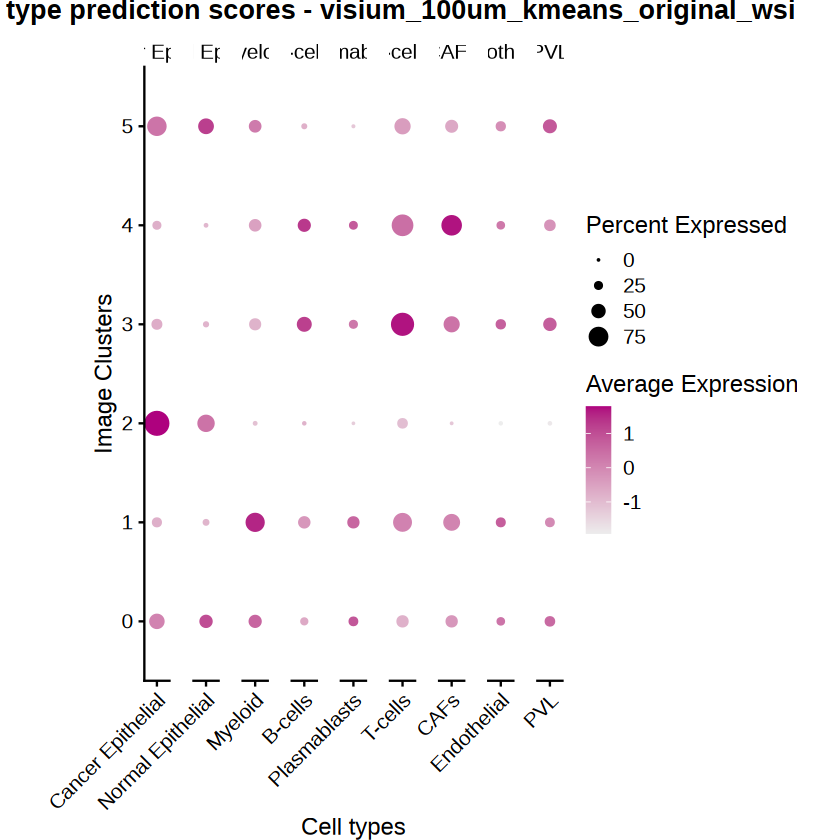

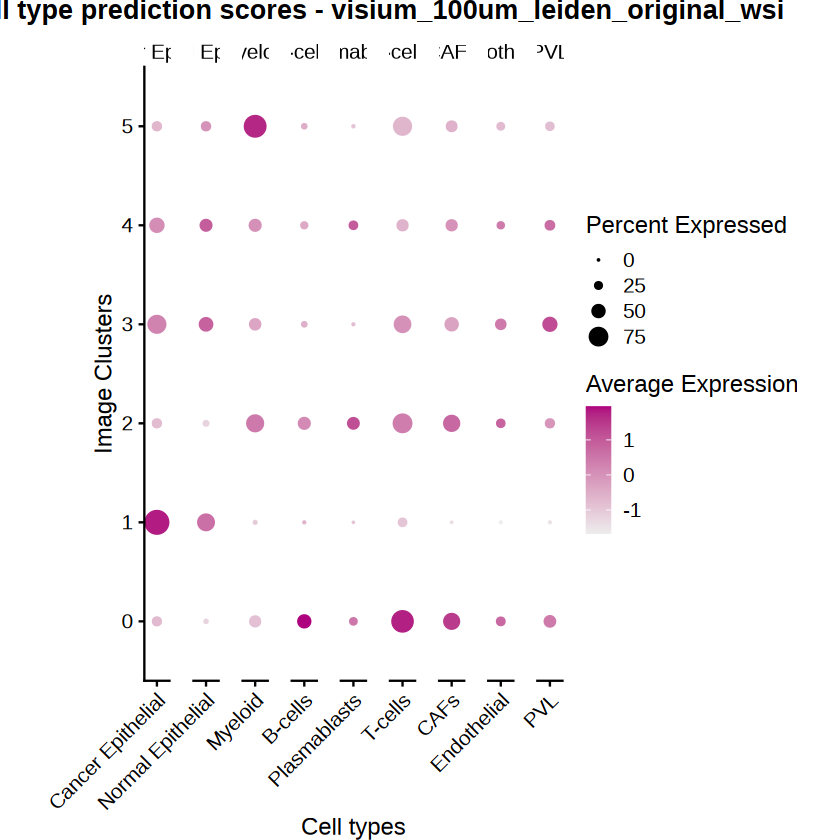

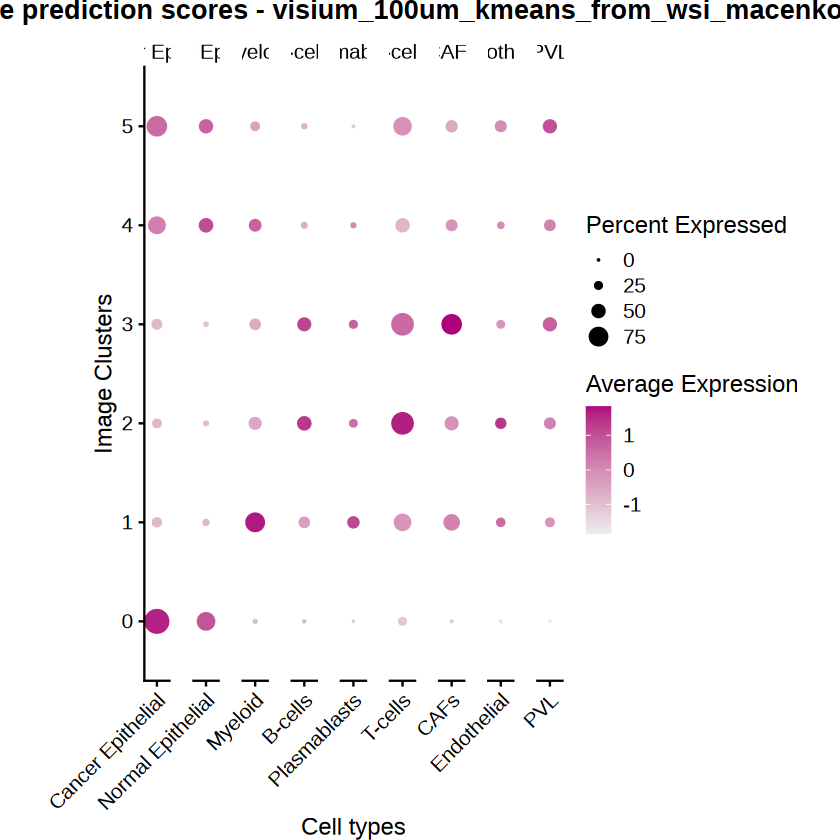

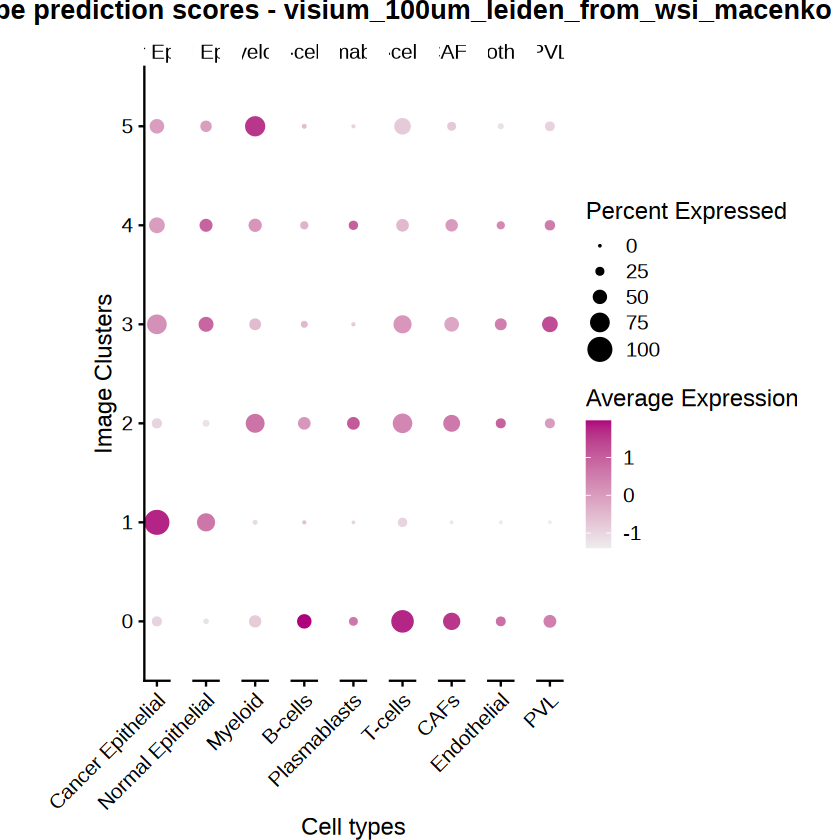

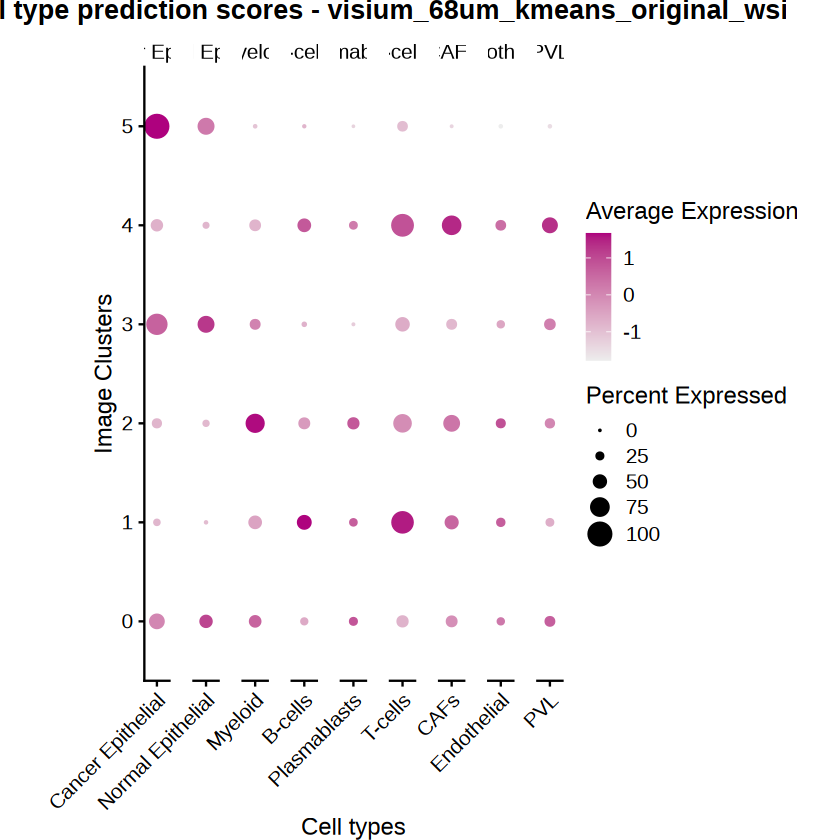

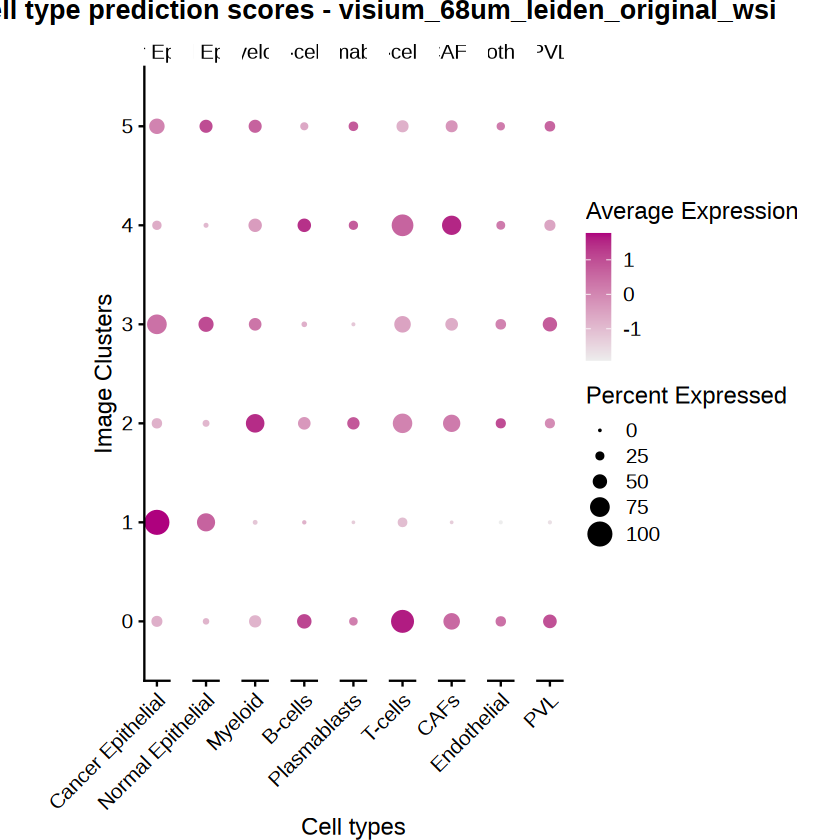

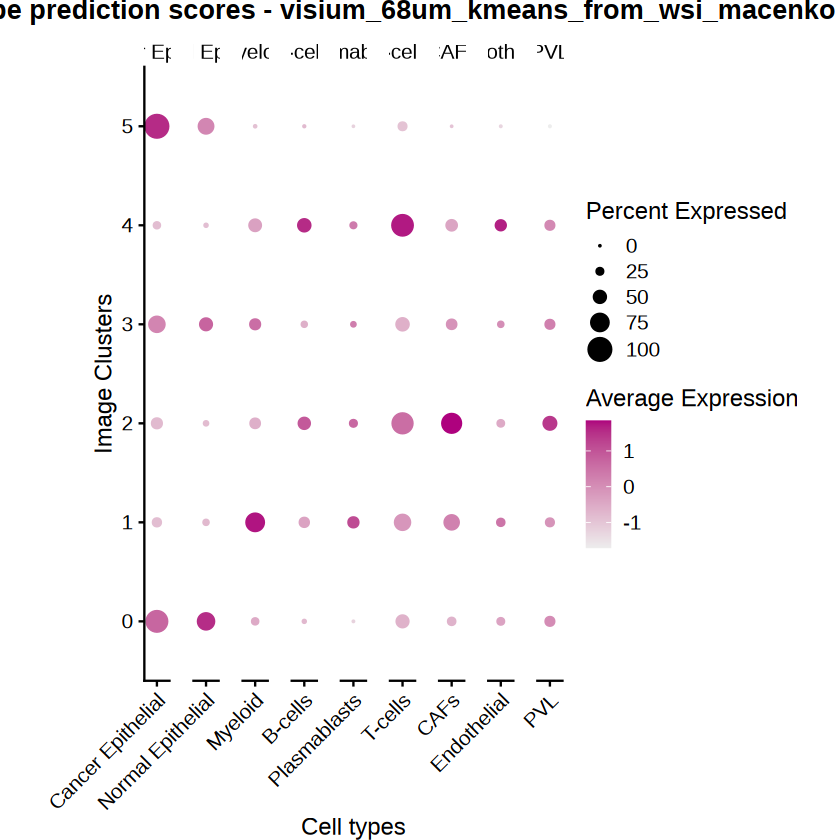

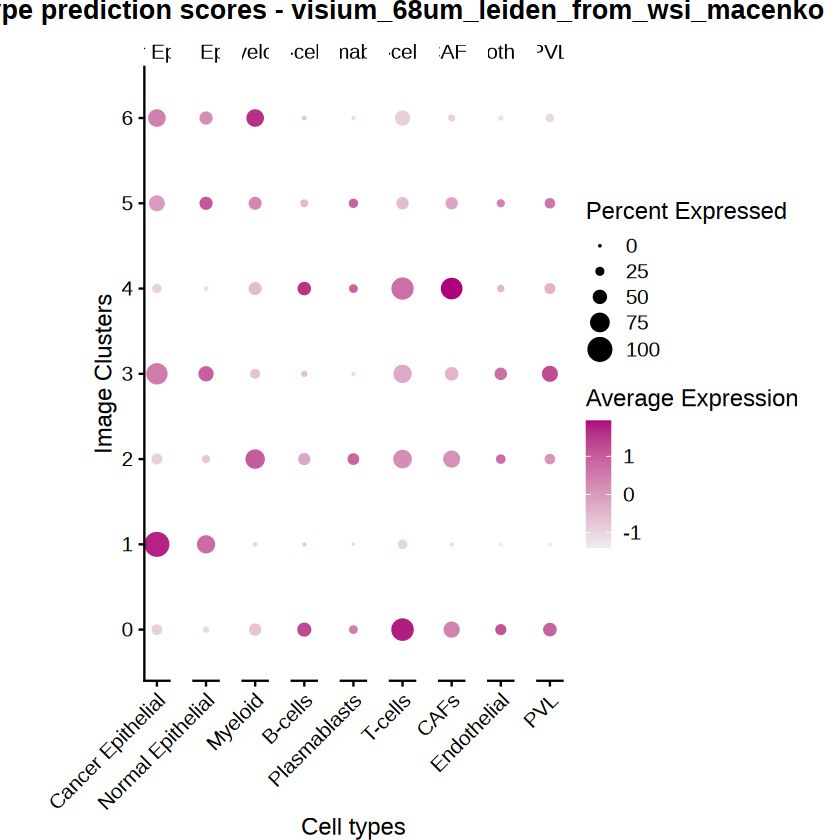

In [84]:
# Loop through each and generate plots
for (name in names(image_cluster_data)) {
  df <- image_cluster_data[[name]]

  # Plot
  p <- plot_visium_dotplot_from_cluster_table(
    cluster_df = df,
    seurat_obj = visium,  # adapt this if using a different object
    cluster_label = paste0(name, "_image_cluster"),
    desired_order = desired_order,
    title = paste("ST cell type prediction scores -", name)
  )

  # Display plot
  print(p)

  # Save to file
  ggsave(paste0("dotplot_", name, ".png"), plot = p, width = 10, height = 5, dpi = 300)
}